# Recommender Baselines — Cold-start vs Warm-start

## Goal
Build and evaluate simple, production-relevant baselines for product recommendation using **implicit feedback** (purchases).  
Focus on two practical settings:

- **Cold-start users:** users not seen during training (new visitors / new customers).
- **Warm-start users:** users with history in training and future purchases in test.

This notebook establishes strong baselines before moving to more advanced recommenders (e.g., item-item similarity, CF, content-based).

## Objectives
This notebook builds a first recommender baseline for Olist with a clear separation of scenarios:

### Scenario A — New users (Cold Start)
Users with **no purchase history in training**.
- Model: **Global Popularity** (most purchased items in training)
- Metric: **HitRate@K** (did we recommend at least one item the user actually bought?)

### Scenario B — Returning users (Warm Start)
Users with purchase history in training.
- This notebook will keep the warm subset ready for the next notebook (Item-Item CF).
- I will evaluate warm users later with personalized recommenders.


## Why split scenarios?
Most collaborative recommenders require user history.  
Cold-start users cannot be personalized without additional user/item features, so i use popularity-based baselines.

## Imports and Path

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"

ORDERS_PATH = RAW_DIR / "olist_orders_dataset.csv"
ITEMS_PATH = RAW_DIR / "olist_order_items_dataset.csv"
CUSTOMERS_PATH = RAW_DIR / "olist_customers_dataset.csv"

## Data Sources
I use the following Olist tables:

- `orders` (filter to delivered orders; provides purchase timestamps)
- `order_items` (maps each order to purchased products)
- `customers` (maps order to stable user identifier `customer_unique_id`)
- `products` + `product_category_name_translation` (category metadata for contextual baselines)


In [23]:
orders_df = pd.read_csv(ORDERS_PATH)
items_df = pd.read_csv(ITEMS_PATH)
customers_df = pd.read_csv(CUSTOMERS_PATH)

orders_df["order_purchase_timestamp"] = pd.to_datetime(
    orders_df["order_purchase_timestamp"], errors="coerce"
)

print("orders:", orders_df.shape)
print("items:", items_df.shape)
print("customers:", customers_df.shape)


orders: (99441, 8)
items: (112650, 7)
customers: (99441, 5)


## Build User–Item Events (Implicit Feedback)

### Keys / Identifiers
- **User ID:** `customer_unique_id` (stable across multiple orders)
- **Item ID:** `product_id`
- **Timestamp:** `order_purchase_timestamp`

### Delivered orders only
Restricting `order_status == "delivered"` to reduce noise (cancellations/unfulfilled orders).

### Output table
`user_item_interactions` contains purchase events:
- user_id, item_id, ts

In [24]:
orders_delivered = orders_df[orders_df["order_status"] == "delivered"].copy()

orders_enriched = orders_delivered.merge(
    customers_df[["customer_id", "customer_unique_id"]], on="customer_id", how="inner"
)

user_item_interactions = (
    orders_enriched[["order_id", "customer_unique_id", "order_purchase_timestamp"]]
    .merge(items_df[["order_id", "product_id"]], on="order_id", how="inner")
    .rename(
        columns={
            "customer_unique_id": "user_id",
            "product_id": "item_id",
            "order_purchase_timestamp": "ts",
        }
    )
)

user_item_interactions = (
    user_item_interactions[["user_id", "item_id", "ts"]]
    .drop_duplicates(["user_id", "item_id", "ts"])
    .copy()
)


**Interaction Definition (Implicit Feedback)**
An **interaction** is a delivered purchase event:
- One row per `(user_id, item_id, ts)` where the user purchased that product.

*Deduplication*

If duplicated rows exist due to joins or repeated records, drop duplicates by `(user_id, item_id, ts)` to avoid double-counting.

In [25]:
print("user_item_interactions:", user_item_interactions.shape)
print("unique users:", user_item_interactions["user_id"].nunique())
print("unique items:", user_item_interactions["item_id"].nunique())
print(
    "min/max ts:",
    user_item_interactions["ts"].min(),
    user_item_interactions["ts"].max(),
)
user_item_interactions.head()

user_item_interactions: (100165, 3)
unique users: 93358
unique items: 32216
min/max ts: 2016-09-15 12:16:38 2018-08-29 15:00:37


,user_id,item_id,ts
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,2017-10-02 10:56:33
1,af07308b275d755c9edb36a90c618231,595fac2a385ac33a80bd5114aec74eb8,2018-07-24 20:41:37
2,3a653a41f6f9fc3d2a113cf8398680e8,aa4383b373c6aca5d8797843e5594415,2018-08-08 08:38:49
3,7c142cf63193a1473d2e66489a9ae977,d0b61bfb1de832b15ba9d266ca96e5b0,2017-11-18 19:28:06
4,72632f0f9dd73dfee390c9b22eb56dd6,65266b2da20d04dbe00c5c2d3bb7859e,2018-02-13 21:18:39


## Cold-start vs Warm-start users

### Train/Test split protocol (global temporal split)
Using a **global time-based split**:

- Sort all interactions by timestamp `ts`
- Select a cutoff at a time quantile (e.g., 80th percentile)
- **Train:** interactions with `ts <= cutoff`
- **Test:** interactions with `ts > cutoff`

Given the temporal split:

- **Cold-start test users:** users that appear in `test` but **not** in `train`
- **Warm-start test users:** users that appear in **both** `train` and `test`

In this dataset + split, warm users may be small because many users purchase only once.
This is an important finding and influences what models are possible to evaluate.

GLOBAL SPLIT
global_train: (80132, 3) unique users: 74736
global_test : (20033, 3) unique users: 19059
cold_test: (19543, 3) unique users: 18622
warm_test: (490, 3) unique users: 437


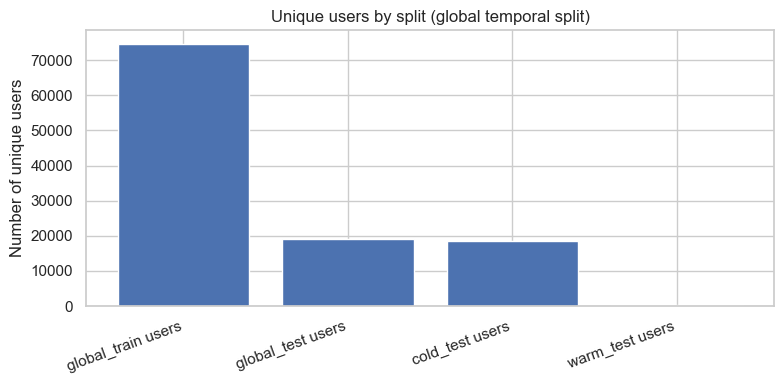

In [26]:
user_item_sorted = user_item_interactions.sort_values("ts").copy()

global_split = user_item_sorted["ts"].quantile(0.80)

global_train = user_item_sorted[user_item_sorted["ts"] <= global_split].copy()
global_test = user_item_sorted[user_item_sorted["ts"] > global_split].copy()

train_users = set(global_train["user_id"].unique())

cold_test = global_test[~global_test["user_id"].isin(train_users)].copy()
warm_test = global_test[global_test["user_id"].isin(train_users)].copy()

print("GLOBAL SPLIT")
print(
    "global_train:",
    global_train.shape,
    "unique users:",
    global_train["user_id"].nunique(),
)
print(
    "global_test :",
    global_test.shape,
    "unique users:",
    global_test["user_id"].nunique(),
)
print("cold_test:", cold_test.shape, "unique users:", cold_test["user_id"].nunique())
print("warm_test:", warm_test.shape, "unique users:", warm_test["user_id"].nunique())


counts_users = {
    "global_train users": global_train["user_id"].nunique(),
    "global_test users": global_test["user_id"].nunique(),
    "cold_test users": cold_test["user_id"].nunique(),
    "warm_test users": warm_test["user_id"].nunique(),
}

plt.figure(figsize=(8, 4))
plt.bar(list(counts_users.keys()), list(counts_users.values()))
plt.title("Unique users by split (global temporal split)")
plt.ylabel("Number of unique users")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


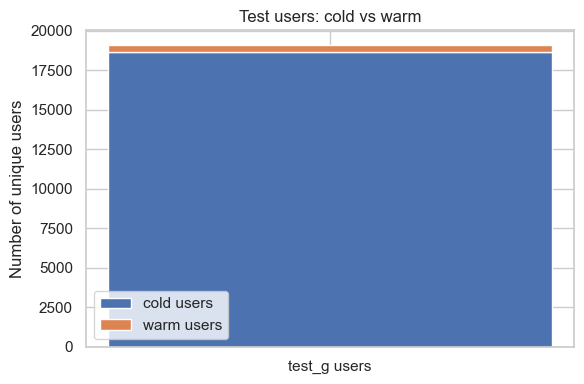

Percentage of Cold users in test: 97.7071199958025
Percentage of Warm users in test: 2.292880004197492


In [27]:
import matplotlib.pyplot as plt

cold_u = cold_test["user_id"].nunique()
warm_u = warm_test["user_id"].nunique()
total_test_u = global_test["user_id"].nunique()

plt.figure(figsize=(6, 4))
plt.bar(["test_g users"], [cold_u], label="cold users")
plt.bar(["test_g users"], [warm_u], bottom=[cold_u], label="warm users")
plt.title("Test users: cold vs warm")
plt.ylabel("Number of unique users")
plt.legend()
plt.tight_layout()
plt.show()

print("Percentage of Cold users in test:", (cold_u / total_test_u) * 100)
print("Percentage of Warm users in test:", (warm_u / total_test_u) * 100)


### Split observations (from data)

- `globa_train`: 80,132 interactions, 74,736 unique users  
- `global_test`:  20,033 interactions, 19,059 unique users  
- `cold_test`: 19,543 interactions, 18,622 unique users  
- `warm_test`:    490 interactions,    437 unique users  

This indicates that the test window is dominated by **cold-start users**:
- Most users in `global_test` are new and do not exist in training.
- Only a small fraction are returning users.

### Implications for recommender evaluation

- **Cold-start evaluation**: Global popularity baselines (Top-K most purchased items) are appropriate because they do not require user history.
- **Warm-user evaluation**: Collaborative filtering methods require user history; however, with this global split, the number of warm users is small, making warm-user evaluation unstable.

Therefore, treat this global split primarily as a **cold-start evaluation setting**, and use alternative protocols (e.g., Leave-One-Out / leave-last-out per user) when focusing on returning users.

## Popularity EDA: Top product categories in training

Before evaluating the popularity baseline, which product categories dominate the training interactions.
This helps interpret why a global popularity baseline behaves the way it does (e.g., it may be biased toward a few high-volume categories).


In [28]:
products_df = pd.read_csv(f"{RAW_DIR}/olist_products_dataset.csv")
category_translation_df = pd.read_csv(
    f"{RAW_DIR}/product_category_name_translation.csv"
)

product_category = products_df[["product_id", "product_category_name"]].merge(
    category_translation_df, on="product_category_name", how="left"
)

train_with_cat = global_train.merge(
    product_category, left_on="item_id", right_on="product_id", how="left"
)

top_categories = (
    train_with_cat.groupby("product_category_name_english")
    .size()
    .sort_values(ascending=False)
    .head(15)
)


top_categories


product_category_name_english
bed_bath_table           8068
health_beauty            6460
sports_leisure           6383
computers_accessories    5562
furniture_decor          5540
housewares               4295
watches_gifts            4237
telephony                3491
toys                     3384
cool_stuff               3243
garden_tools             3081
auto                     2932
perfumery                2591
baby                     2200
electronics              2081
dtype: int64

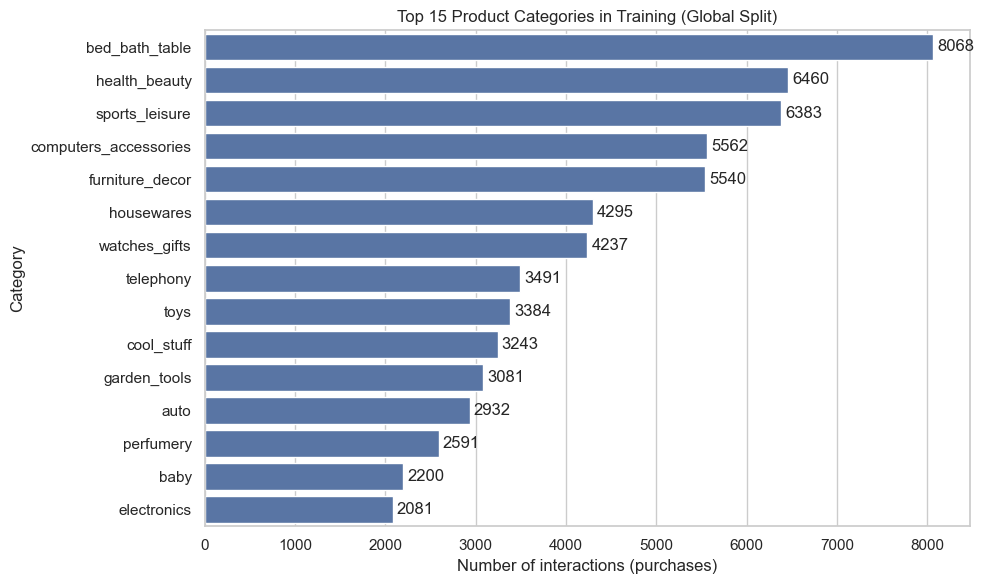

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df_top = top_categories.reset_index()
df_top.columns = ["category", "count"]

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_top, x="count", y="category")
ax.set_title("Top 15 Product Categories in Training (Global Split)")
ax.set_xlabel("Number of interactions (purchases)")
ax.set_ylabel("Category")

# add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()


## Baseline A — Global Popularity (Non-personalized)
**Idea:** recommend the same Top-K most purchased items from training to every user.

This baseline is a proxy for a **homepage / trending products** module.

### Training
Compute item popularity on train:
- `popularity(item) = number of train purchase events containing item`

### Recommendation
- `recs(u, K) = TopK_global_popularity`

In [30]:
# popularity as series
popularity = global_train.groupby("item_id").size().sort_values(ascending=False)

# table to display
top_items_counts = popularity.head(15).reset_index()
top_items_counts.columns = ["item_id", "count"]

top_items = popularity.index.to_list()
top_items[:5]

['99a4788cb24856965c36a24e339b6058',
 'aca2eb7d00ea1a7b8ebd4e68314663af',
 '422879e10f46682990de24d770e7f83d',
 '53b36df67ebb7c41585e8d54d6772e08',
 '389d119b48cf3043d311335e499d9c6b']

In [31]:
# build product -> category mapping (english)
product_category = product_category.rename(
    columns={"product_id": "item_id", "product_category_name_english": "category"}
).fillna("Unknown")

top_items_named = top_items_counts.merge(
    product_category[["item_id", "category"]], on="item_id", how="left"
)
top_items_named


,item_id,count,category
0,99a4788cb24856965c36a24e339b6058,419,bed_bath_table
1,aca2eb7d00ea1a7b8ebd4e68314663af,418,furniture_decor
2,422879e10f46682990de24d770e7f83d,335,garden_tools
3,53b36df67ebb7c41585e8d54d6772e08,283,watches_gifts
4,389d119b48cf3043d311335e499d9c6b,283,garden_tools
5,368c6c730842d78016ad823897a372db,270,garden_tools
6,d1c427060a0f73f6b889a5c7c61f2ac4,268,computers_accessories
7,53759a2ecddad2bb87a079a1f1519f73,267,garden_tools
8,154e7e31ebfa092203795c972e5804a6,254,health_beauty
9,2b4609f8948be18874494203496bc318,224,health_beauty


## Cold-start evaluation: HitRate@K

HitRate@K measures whether at least one true purchased item for a cold user
appears within the Top-K recommended list.


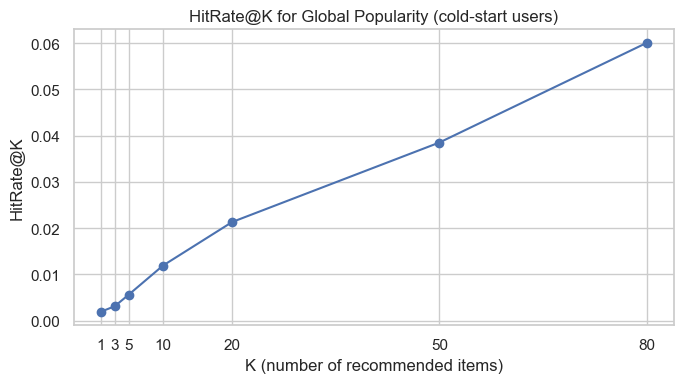

[(1, np.float64(0.001933197293523789)),
 (3, np.float64(0.0031145956395661045)),
 (5, np.float64(0.0055847921812909465)),
 (10, np.float64(0.011921383310063366)),
 (20, np.float64(0.021318870153581786)),
 (50, np.float64(0.03850284609601547)),
 (80, np.float64(0.06003651594887767))]

In [32]:
truth_cold = cold_test.groupby("user_id")["item_id"].apply(set).to_dict()


def hitrate_at_k(truth_set, recs):
    return 1 if len(set(recs) & truth_set) > 0 else 0


Ks = [1, 3, 5, 10, 20, 50, 80]
hit_rates = []

for K in Ks:
    recs_k = top_items[:K]
    hits = [hitrate_at_k(truth_u, recs_k) for truth_u in truth_cold.values()]
    hit_rates.append(np.mean(hits))

plt.figure(figsize=(7, 4))
plt.plot(Ks, hit_rates, marker="o")
plt.title("HitRate@K for Global Popularity (cold-start users)")
plt.xlabel("K (number of recommended items)")
plt.ylabel("HitRate@K")
plt.xticks(Ks)
plt.tight_layout()
plt.show()

list(zip(Ks, hit_rates))


## Baseline B — Category Popularity (Contextual, still non-personalized)
**Idea:** if we know a category context (example: the user is browsing a category page),
recommend Top-K most popular items **within that category**, computed from training.

This baseline is a proxy for a **category page recommender**.

### Training
For each category `c`, compute:
- `TopK_items_in_cat[c]` based on training purchase counts within `c`

In [33]:
prod_cat = (
    products_df[["product_id", "product_category_name"]]
    .merge(
        category_translation_df, on="product_category_name", how="left"
    )  # adds product_category_name_english
    .rename(
        columns={"product_id": "item_id", "product_category_name_english": "category"}
    )
)[["item_id", "category"]]

train_cat = global_train.merge(prod_cat, on="item_id", how="left")
cold_cat = cold_test.merge(prod_cat, on="item_id", how="left")

print("missing category (train):", train_cat["category"].isna().mean())
print("missing category (cold):", cold_cat["category"].isna().mean())


missing category (train): 0.016348025757500124
missing category (cold): 0.005526275392723737


In [34]:
# Popular items per category (from training)
# We'll store: top_items_by_cat[category] = [item1, item2, ...] sorted by popularity in that category
top_items_by_cat = {}

cat_counts = (
    train_cat.dropna(subset=["category"])
    .groupby(["category", "item_id"])
    .size()
    .sort_values(ascending=False)
)

for (cat, item), cnt in cat_counts.items():
    top_items_by_cat.setdefault(cat, []).append(item)

# quick check
some_cat = next(iter(top_items_by_cat.keys()))
some_cat, top_items_by_cat[some_cat][:10]


('bed_bath_table',
 ['99a4788cb24856965c36a24e339b6058',
  'f1c7f353075ce59d8a6f3cf58f419c9c',
  'ec2d43cc59763ec91694573b31f1c29a',
  '06edb72f1e0c64b14c5b79353f7abea3',
  '777d2e438a1b645f3aec9bd57e92672c',
  '84f456958365164420cfc80fbe4c7fab',
  '363218ba55c610b750224f90bdd34be1',
  '2a2d22ae30e026f1893083c8405ca522',
  '64fb265487de2238627ce43fe8a67efc',
  '25f86162fee18735fffdb762dcb10d7c'])

## Baseline C — Geo Popularity (Cold-start, leakage-free)

Cold-start users have no behavioral history, but we may still have non-behavioral context such as location.
Computing Top-K purchased items per `customer_state` using **training data only**.

### Training
For each state `s`, build a ranked list:
- `TopK_items_in_state[s]` sorted by purchase counts in training.

### Recommendation
For a user `u` with known `state(u)=s`:
- `Recs(u, K) = TopK_items_in_state[s][:K]`
If the state is missing or unseen in training, fall back to global popularity.

This baseline provides realistic cold-start personalization without using any future test behavior.

### User -> state mapping from customers data (no test)

In [35]:
# user -> state mapping from customers data (no test behavior)
user_state = (
    customers_df[["customer_unique_id", "customer_state"]]
    .dropna()
    .groupby("customer_unique_id")["customer_state"]
    .agg(lambda s: s.value_counts().index[0])
)

### Top items per state (from TRAIN ONLY)

In [36]:
# Top items per state computed from TRAIN only
train_geo = global_train.copy()
train_geo["state"] = train_geo["user_id"].map(user_state)

state_item_counts = (
    train_geo.dropna(subset=["state"])
    .groupby(["state", "item_id"])
    .size()
    .reset_index(name="cnt")
    .sort_values(["state", "cnt"], ascending=[True, False])
)

top_items_by_state = state_item_counts.groupby("state")["item_id"].apply(list).to_dict()

print("States with Top-K lists:", len(top_items_by_state))
print(
    "Share of TRAIN interactions with known state:",
    float(train_geo["state"].notna().mean()),
)


States with Top-K lists: 27
Share of TRAIN interactions with known state: 1.0


### Evaluate on cold start users (user-level HitRate@K) Global vs Geo

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# to evaluate cold-start users
cold_geo = cold_test.copy()
truth_cold = cold_geo.groupby("user_id")["item_id"].apply(set).to_dict()

Ks = [1, 3, 5, 10, 20, 50]

# Global baseline
hit_rates_global = []
for K in Ks:
    recs_k = top_items[:K]
    hits = [hitrate_at_k(truth_u, recs_k) for truth_u in truth_cold.values()]
    hit_rates_global.append(float(np.mean(hits)))

# Geo baseline (fallback to global)
hit_rates_geo = []
fallback_share = []

cold_users = list(truth_cold.keys())

for K in Ks:
    hits = []
    fb = 0
    for u in cold_users:
        st = user_state.get(u, None)
        rec_list = top_items_by_state.get(st, None)

        if rec_list is None:  # unknown/unseen state
            fb += 1
            rec_list = top_items

        hits.append(hitrate_at_k(truth_cold[u], rec_list[:K]))

    hit_rates_geo.append(float(np.mean(hits)))
    fallback_share.append(fb / len(cold_users))

results_geo = pd.DataFrame(
    {
        "K": Ks,
        "HitRate_global": hit_rates_global,
        "HitRate_geo": hit_rates_geo,
        "fallback_share": fallback_share,
    }
)


#### Lift Geo vs Popularity

,K,Global,Geo,Absolute_gain (Geo-Global)
0,1,0.001933,0.002202,0.000268
1,3,0.003115,0.005692,0.002578
2,5,0.005585,0.007572,0.001987
3,10,0.011921,0.012942,0.001020
4,20,0.021319,0.023198,0.001879
5,50,0.038503,0.042745,0.004242


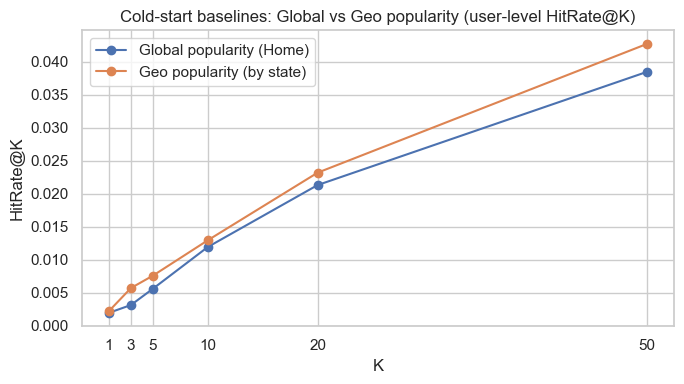

In [38]:
diff = np.array(hit_rates_geo) - np.array(hit_rates_global)

summary = pd.DataFrame(
    {
        "K": Ks,
        "Global": hit_rates_global,
        "Geo": hit_rates_geo,
        "Absolute_gain (Geo-Global)": diff,
    }
)

display(summary)
plt.figure(figsize=(7, 4))
plt.plot(Ks, hit_rates_global, marker="o", label="Global popularity (Home)")
plt.plot(Ks, hit_rates_geo, marker="o", label="Geo popularity (by state)")
plt.title("Cold-start baselines: Global vs Geo popularity (user-level HitRate@K)")
plt.xlabel("K")
plt.ylabel("HitRate@K")
plt.xticks(Ks)
plt.legend()
plt.tight_layout()
plt.show()

#### Hitrate by state

In [39]:
K = 50

# assign each cold user a state
cold_user_state = pd.Series(
    {u: user_state.get(u, None) for u in truth_cold.keys()}, name="state"
)

# evaluate per state
rows = []
for st, users_in_st in cold_user_state.dropna().groupby(cold_user_state).groups.items():
    users_in_st = list(users_in_st)
    recs = top_items_by_state.get(st, top_items)[:K]
    hr = np.mean([hitrate_at_k(truth_cold[u], recs) for u in users_in_st])
    rows.append((st, len(users_in_st), hr))

state_perf = pd.DataFrame(
    rows, columns=["state", "n_cold_users", f"HitRate@{K}"]
).sort_values("n_cold_users", ascending=False)
display(state_perf.head(10))

,state,n_cold_users,HitRate@50
25,SP,8614,0.040051
18,RJ,2117,0.045820
10,MG,2058,0.056851
17,PR,943,0.030753
22,RS,906,0.028698
4,BA,614,0.052117
23,SC,596,0.043624
6,DF,454,0.037445
7,ES,349,0.031519
8,GO,328,0.070122


**Assumption:** We assume `customer_state` is known at inference time (e.g., user profile, shipping region, or session geo).  
If location is unavailable (anonymous traffic), we fall back to global popularity.

### Result interpretation
Geo popularity consistently outperforms global popularity on cold-start users.
Reporting both curves (Global vs Geo) and the absolute gain (Geo − Global), which is easier to interpret than relative lift when baseline rates are small.

## Evaluation Metrics

### User HitRate@K
For each user `u`, let `Truth(u)` be the set of items purchased in test.
Let `Recs(u, K)` be the recommended Top-K list.

Scoring :
- `hit(u, K) = 1 if Recs(u,K) ∩ Truth(u) ≠ ∅ else 0`
- `HitRate@K = mean_u hit(u,K)`

This metric answers: **"For how many users did we recommend at least one item they actually bought?"**

### Event HitRate@K (Contextual)
For each test event `(u, item, context)`:
- `hit_event = 1 if item ∈ TopK(context) else 0`
- `EventHitRate@K = mean(hit_event)`

This metric answers: **"For a random purchase event, how often is the purchased item in the Top-K list for that context?"**

### Cold-start evaluation for category baseline

For each cold user we assume a category context is available.
A simple proxy is to use the category of the item(s) the user purchased in test
(as if the user was browsing that category).

For each user:
- Determine one context category (e.g., the most frequent category in their test purchases)
- Recommend Top-K items from that category popularity list
- Evaluate HitRate@K


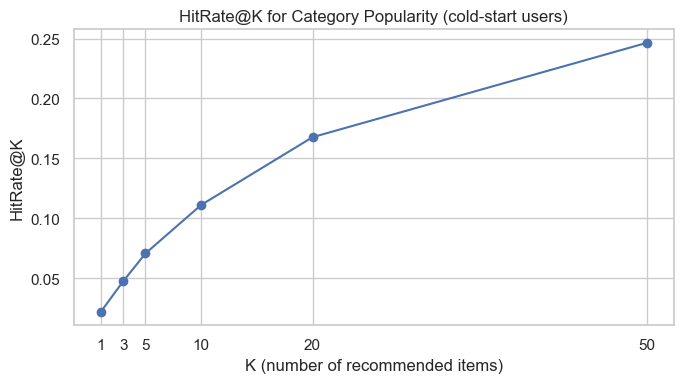

[(1, np.float64(0.021916329284750336)),
 (3, np.float64(0.04728744939271255)),
 (5, np.float64(0.07055330634278002)),
 (10, np.float64(0.1110391363022942)),
 (20, np.float64(0.16761133603238867)),
 (50, np.float64(0.2463697705802969))]

In [40]:
def user_context_category(user_rows):
    # choose the most frequent category among the user's test purchases
    # (simple proxy for "category page" context)
    vc = user_rows["category"].value_counts()
    if len(vc) == 0:
        return None
    return vc.index[0]


Ks = [1, 3, 5, 10, 20, 50]
hit_rates_cat = []

cold_grouped = cold_cat.dropna(subset=["category"]).groupby("user_id")

for K in Ks:
    hits = []
    for u, rows in cold_grouped:
        cat = user_context_category(rows)
        if cat is None or cat not in top_items_by_cat:
            continue
        recs_k = top_items_by_cat[cat][:K]
        truth_u = set(rows["item_id"].tolist())
        hits.append(hitrate_at_k(truth_u, recs_k))
    hit_rates_cat.append(np.mean(hits))

plt.figure(figsize=(7, 4))
plt.plot(Ks, hit_rates_cat, marker="o")
plt.title("HitRate@K for Category Popularity (cold-start users)")
plt.xlabel("K (number of recommended items)")
plt.ylabel("HitRate@K")
plt.xticks(Ks)
plt.tight_layout()
plt.show()

list(zip(Ks, hit_rates_cat))


### Cold-start contextual baseline (event-level): Global vs Category Popularity

**What does “contextual” mean?**

A “contextual” recommender conditions its suggestions on an observable signal from the current session/page, such as:

the category being browsed (category page), a search query, active filters, session information, etc.

In this experiment, i use the product category as the context (category page scenario).

**Baselines compared**

Global popularity (Home)
Recommend the Top-K most popular items overall (computed from training data only).

Category popularity (Category page)
Recommend the Top-K most popular items within the observed category context (also computed from training data only).

**This evaluation is non-leaky because**:

Popularity rankings are built strictly from the training split.

The test split is only used to check whether the purchased item was included in the Top-K list under the observed context.

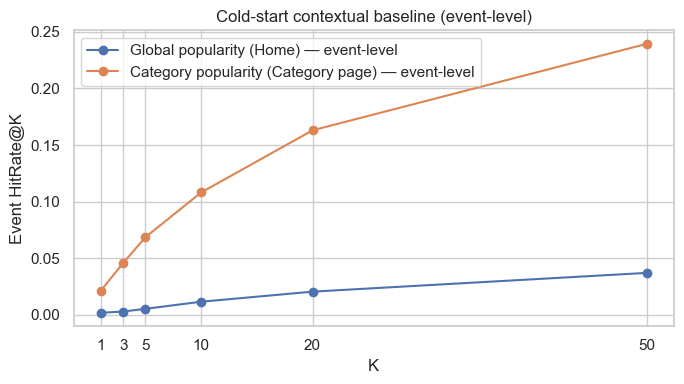

,K,EventHitRate_global,EventHitRate_category
0,1,0.001852,0.021456
1,3,0.002984,0.045794
2,5,0.005351,0.068639
3,10,0.011629,0.108104
4,20,0.020530,0.163005
5,50,0.037098,0.239362


In [41]:
Ks = [1, 3, 5, 10, 20, 50]

# Cold events with a valid category that exists in the top dictionary by category
cold_events = cold_cat.dropna(subset=["category"]).copy()
cold_events = cold_events[cold_events["category"].isin(top_items_by_cat.keys())]

# Baseline 1: Global popularity (Home) — event-level
hit_global_event = []
for K in Ks:
    recs_k = top_items[:K]  # global top-K (from TRAIN)
    hit_global_event.append(cold_events["item_id"].isin(recs_k).mean())

# Baseline 2: Category popularity (Category page) — event-level
hit_rates_cat_event = []
for K in Ks:
    total_hits = 0
    total_events = 0

    for cat, grp in cold_events.groupby("category"):
        recs_k = top_items_by_cat[cat][:K]  # top-K of that category (from TRAIN)
        total_hits += grp["item_id"].isin(recs_k).sum()
        total_events += len(grp)

    hit_rates_cat_event.append(total_hits / total_events)


# 4) Comparative plot of event-level Global vs Category baselines
plt.figure(figsize=(7, 4))
plt.plot(
    Ks, hit_global_event, marker="o", label="Global popularity (Home) — event-level"
)
plt.plot(
    Ks,
    hit_rates_cat_event,
    marker="o",
    label="Category popularity (Category page) — event-level",
)
plt.title("Cold-start contextual baseline (event-level)")
plt.xlabel("K")
plt.ylabel("Event HitRate@K")
plt.xticks(Ks)
plt.legend()
plt.tight_layout()
plt.show()

# 5) Tabla
results = pd.DataFrame(
    {
        "K": Ks,
        "EventHitRate_global": hit_global_event,
        "EventHitRate_category": hit_rates_cat_event,
    }
)
results


## Cold-start baselines comparision: Home (global) vs Category Page (category popularity)

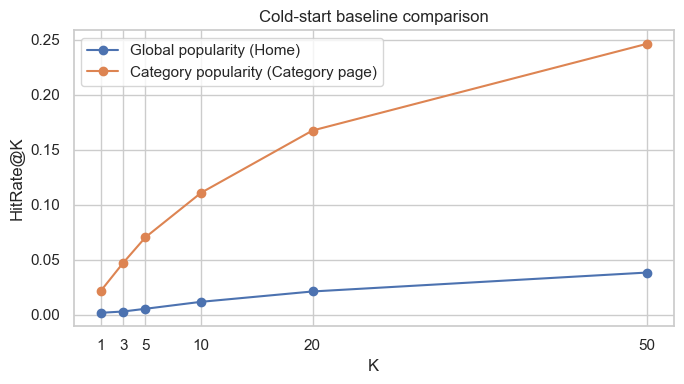

,K,HitRate_global,HitRate_category
0,1,0.001933,0.021916
1,3,0.003115,0.047287
2,5,0.005585,0.070553
3,10,0.011921,0.111039
4,20,0.021319,0.167611
5,50,0.038503,0.246370


In [42]:
# Compare both curves on one plot (for same Ks)
Ks_common = [1, 3, 5, 10, 20, 50]

# global for Ks_common
hit_global_common = []
for K in Ks_common:
    recs_k = top_items[:K]
    hits = [hitrate_at_k(truth_u, recs_k) for truth_u in truth_cold.values()]
    hit_global_common.append(np.mean(hits))

plt.figure(figsize=(7, 4))
plt.plot(Ks_common, hit_global_common, marker="o", label="Global popularity (Home)")
plt.plot(
    Ks_common, hit_rates_cat, marker="o", label="Category popularity (Category page)"
)
plt.title("Cold-start baseline comparison")
plt.xlabel("K")
plt.ylabel("HitRate@K")
plt.xticks(Ks_common)
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "K": Ks_common,
        "HitRate_global": hit_global_common,
        "HitRate_category": hit_rates_cat,
    }
).reset_index(drop=True)


## Persist results

In [ ]:
# top_items_by_state: dict[str, list[str]]  (o list of item_ids)

state_recs = {
    st: [{"item_id": iid, "rank": r + 1} for r, iid in enumerate(items[:200])]
    for st, items in top_items_by_state.items()
}

In [44]:
import json
import psycopg
from src.db.conn import get_db_conninfo

CONNINFO = get_db_conninfo()
MODEL = "geo_popularity_v1"

with psycopg.connect(CONNINFO) as conn:
    with conn.cursor() as cur:
        for state, recs in state_recs.items():
            cur.execute(
                """
                INSERT INTO recommendations_context (context_type, context_value, model, recs)
                VALUES (%s, %s, %s, %s::jsonb)
                ON CONFLICT (context_type, context_value, model)
                DO UPDATE SET recs = EXCLUDED.recs, generated_at = now();
                """,
                ("state", state, MODEL, json.dumps(recs)),
            )
    conn.commit()

print("Upserted states:", len(state_recs), "| model:", MODEL)

Upserted states: 27 | model: geo_popularity_v1


## Conclusions (Cold-start baselines)
- The global temporal split creates a test window dominated by **new users**, which is a realistic cold-start setting.
- **Global popularity** is a valid homepage fallback but may achieve limited HitRate@K due to large catalog size.
- **Category popularity** can improve HitRate@K when category context is available.

## Limitations
- The global temporal split can yield very few warm users because many users purchase only once.
- The "oracle category" user-level variant is not deployable as-is (uses future information), but useful as an upper bound.
- Popularity baselines do not personalize recommendations and can over-recommend already dominant categories/items.

## Next Steps
- Warm-start evaluation with a per-user split (leave-last-out) to enable CF-style models.
- Item-item similarity (co-occurrence / cosine) for lightweight personalization.
- Content-based models using product metadata and/or review text embeddings.
- Report additional metrics: coverage, novelty, and diversity (optional but good for portfolios).
